# Zipf's Law

In [1]:
import sys

if ".." not in sys.path:
    sys.path.append("..")

import polars as pl
import matplotlib.pyplot as plt
from random import choice

In [2]:
c = pl.read_parquet("latimes.parquet").with_columns(
    word=pl.col("token").str.to_lowercase()
)

In [3]:
c

token,lemma,xpos,pos,sentence_tag,doc_id,word
str,str,str,str,str,str,str
"""A""","""a""","""DT""","""DET""","""I""","""article_00000""","""a"""
"""prep""","""prep""","""JJ""","""ADJ""","""I""","""article_00000""","""prep"""
"""course""","""course""","""NN""","""NOUN""","""I""","""article_00000""","""course"""
"""for""","""for""","""IN""","""ADP""","""I""","""article_00000""","""for"""
"""the""","""the""","""DT""","""DET""","""I""","""article_00000""","""the"""
…,…,…,…,…,…,…
"""But""","""but""","""CC""","""CCONJ""","""I""","""article_01181""","""but"""
"""the""","""the""","""DT""","""DET""","""I""","""article_01181""","""the"""
"""bet""","""bet""","""NN""","""NOUN""","""I""","""article_01181""","""bet"""


Rank vs Frequency

In [4]:
def get_ranks(df):
    return (
        df.lazy()
        .group_by("word")
        .len("freq")
        .sort(by="freq", descending=True)
        .with_row_index("rank", offset=1)
        .collect()
    )

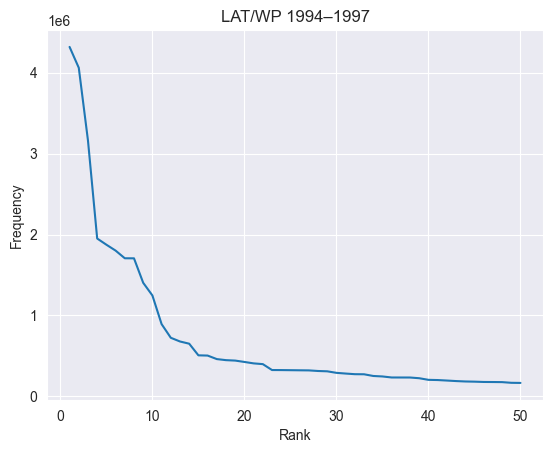

In [5]:
r = get_ranks(c).head(50)
plt.plot(r["rank"], r["freq"])
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("LAT/WP 1994–1997")
plt.show()

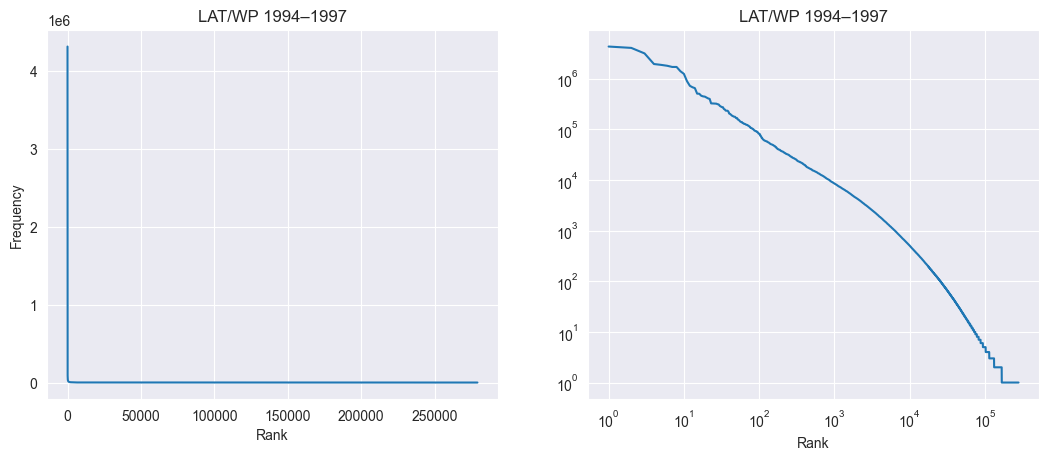

In [6]:
r = get_ranks(c)

# array([6.4*2, 4.8])

plt.figure(figsize=(6.4 * 2, 4.8))

plt.subplot(1, 2, 1)
plt.plot(r["rank"], r["freq"])
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("LAT/WP 1994–1997")

plt.subplot(1, 2, 2)
plt.plot(r["rank"], r["freq"])
plt.xlabel("Rank")
# plt.ylabel('Frequency')
plt.title("LAT/WP 1994–1997")
plt.loglog()

plt.show()

Scale invariance

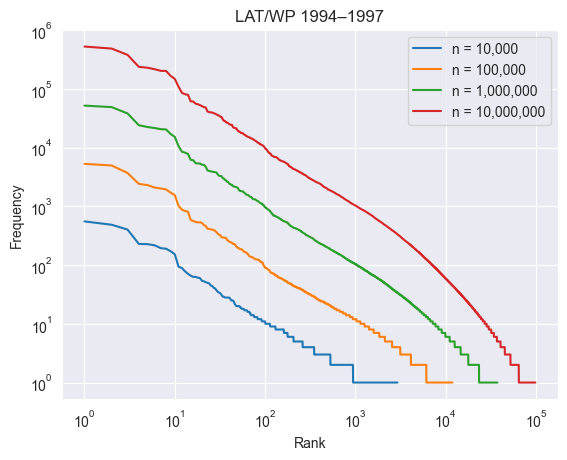

In [7]:
for n in [10_000, 100_000, 1_000_000, 10_000_000]:
    r = get_ranks(c.head(n))
    plt.plot(r["rank"], r["freq"], label=f"n = {n:,}")

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("LAT/WP 1994–1997")
plt.loglog()
plt.legend()
plt.show()

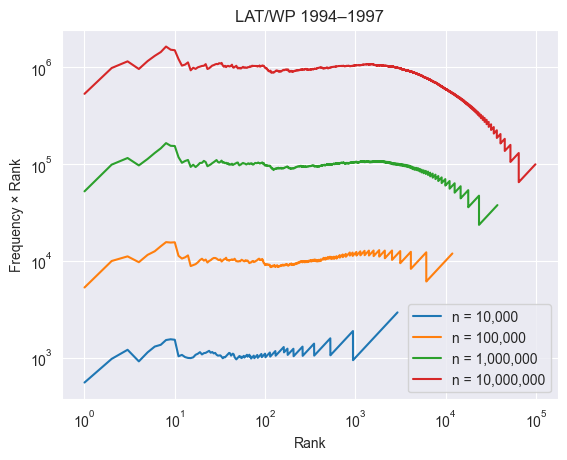

In [8]:
for n in [10_000, 100_000, 1_000_000, 10_000_000]:
    r = get_ranks(c.head(n)).with_columns(k=pl.col("freq") * pl.col("rank"))
    plt.plot(r["rank"], r["k"], label=f"n = {n:,}")

plt.xlabel("Rank")
plt.ylabel("Frequency × Rank")
plt.title("LAT/WP 1994–1997")
plt.loglog()
plt.legend(loc="lower right")
plt.show()

Random text

In [9]:
letters = list("abcd ")
text = "".join([choice(letters) for _ in range(100000000)])
tokens = text.split()
random_c = pl.DataFrame({"word": tokens})

/Users/malouf/Dropbox/code/polars_corpus/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9251 (\N{OPEN BOX}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


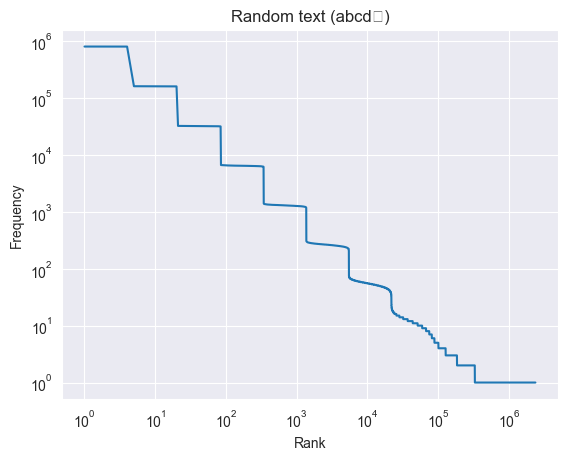

In [10]:
r = get_ranks(random_c)

plt.plot(r["rank"], r["freq"])
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Random text (abcd␣)")
plt.loglog()
plt.show()

Relative frequency

In [11]:
r = []
for n in [10_000, 100_000, 1_000_000, 10_000_000, 50_000_000, 80_000_000]:
    r.append(
        get_ranks(c.head(n)).with_columns(
            rel_freq=pl.col("freq") / pl.col("freq").sum(), n=n
        )
    )
r = pl.concat(r).select("word", "n", "rel_freq").pivot(on="n", index="word")
# .drop_nulls()

In [12]:
r.filter(pl.col("word").is_in(["the", "news", "senate", "york", "ski", "shabazz"]))

word,10000,100000,1000000,10000000,50000000,80000000
str,f64,f64,f64,f64,f64,f64
"""the""",0.0486,0.05292,0.051905,0.0525908,0.052101,0.0518888
"""york""",0.0011,0.0004,0.000388,0.0003877,0.000418,0.000408
"""news""",0.0008,0.00054,0.00062,0.0006899,0.000683,0.000689
"""senate""",0.0001,0.00022,0.000258,0.0004462,0.0004527,0.000401
"""ski""",null,null,null,0.00001,0.000016,0.000014
"""shabazz""",null,null,null,0.0000002,0.000006,0.000007
